<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Crop_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crop Prediction



```
!pip install scikit-learn
```



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/Crop.csv")

df.head()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B,label
0,143,69,217,5.9,0.58,0.23,10.20,116.35,59.96,54.85,21.29,pomegranate
1,170,36,216,5.9,0.15,0.28,15.69,114.20,56.87,31.28,28.62,pomegranate
2,158,66,219,6.8,0.34,0.20,15.29,65.87,51.81,57.12,27.59,pomegranate
3,133,45,207,6.4,0.94,0.21,8.48,103.10,43.81,68.50,47.29,pomegranate
4,132,48,218,6.7,0.54,0.19,5.59,63.40,56.40,46.71,31.04,pomegranate


In [19]:
df.describe()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B
count,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000
mean,135.701613,52.508065,161.401613,6.106290,0.885468,0.484085,17.315452,117.212500,219.905887,34.340839,28.750710
std,31.808083,24.673538,81.285780,0.693782,0.637214,5.775388,6.441150,62.775199,341.998793,11.543871,19.636447
min,30.000000,10.000000,51.000000,4.500000,0.010000,0.011100,0.180000,3.810000,20.580000,17.990000,1.020000
25%,116.000000,30.000000,89.000000,5.700000,0.297500,0.086000,12.592500,68.312500,58.785000,24.727500,13.442500
50%,138.000000,54.000000,157.500000,6.100000,0.780000,0.168000,16.910000,108.245000,73.580000,31.425000,23.225000
75%,160.000000,75.000000,206.000000,6.500000,1.390000,0.240000,21.102500,155.620000,163.665000,43.542500,42.767500
max,198.000000,100.000000,369.000000,8.000000,2.480000,113.200000,35.000000,276.720000,1572.540000,70.000000,74.560000


# Separate Features and Target

In [3]:
features = df.drop('label', axis=1)
target = df['label']

or

In [4]:
X = df[['N',	'P',	'K',	'ph',	'EC',	'S',	'Cu',	'Fe',	'Mn',	'Zn',	'B']]
y = df['label']

or

In [9]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [10]:
X

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B
0,143,69,217,5.9,0.58,0.23000,10.20,116.35,59.96,54.85,21.29
1,170,36,216,5.9,0.15,0.28000,15.69,114.20,56.87,31.28,28.62
2,158,66,219,6.8,0.34,0.20000,15.29,65.87,51.81,57.12,27.59
3,133,45,207,6.4,0.94,0.21000,8.48,103.10,43.81,68.50,47.29
4,132,48,218,6.7,0.54,0.19000,5.59,63.40,56.40,46.71,31.04
...,...,...,...,...,...,...,...,...,...,...,...
615,41,23,135,5.0,1.67,0.10655,26.00,39.20,206.89,31.09,20.64
616,49,45,90,5.8,1.98,0.09229,19.00,40.20,91.12,32.68,14.91
617,131,24,121,4.9,2.24,0.08775,22.00,40.00,94.34,24.93,23.74
618,131,55,130,5.3,2.48,0.08983,15.00,41.00,92.58,45.73,21.48


In [11]:
y

,label
0,pomegranate
1,pomegranate
2,pomegranate
3,pomegranate
4,pomegranate
...,...
615,potato
616,potato
617,potato
618,potato


In [12]:
y.value_counts()

,count
label,
pomegranate,104
mango,104
grapes,104
mulberry,104
ragi,104
potato,100


https://github.com/lovnishverma/Python-Getting-Started/blob/main/Distribute_Datasets_for_Classification_Models.ipynb

https://lovnish.medium.com/understanding-and-handling-imbalanced-datasets-in-classification-models-bb10ac6fa1a7

In [13]:
# train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
X_train.describe()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B
count,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000
mean,136.477823,52.500000,162.705645,6.114919,0.881794,0.565803,17.207460,118.600242,221.061008,34.457440,28.709355
std,31.688055,24.274607,81.627919,0.694407,0.628641,6.455623,6.447591,63.377239,344.385068,11.706243,19.783541
min,30.000000,10.000000,51.000000,4.500000,0.010000,0.011100,0.180000,3.810000,20.580000,17.990000,1.020000
25%,116.000000,30.000000,90.750000,5.700000,0.310000,0.087087,12.592500,69.125000,59.505000,25.032500,13.167500
50%,139.000000,53.000000,157.500000,6.100000,0.780000,0.167500,16.745000,108.945000,73.580000,31.230000,23.225000
75%,161.000000,74.250000,207.000000,6.500000,1.375000,0.240000,21.315000,157.287500,167.945000,43.542500,43.635000
max,198.000000,99.000000,369.000000,8.000000,2.480000,113.200000,35.000000,276.720000,1572.540000,70.000000,74.150000


In [22]:
X_test.describe()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B
count,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000
mean,132.596774,52.540323,156.185484,6.071774,0.900161,0.157211,17.747419,111.661532,215.285403,33.874435,28.916129
std,32.225809,26.311888,80.015585,0.693003,0.672864,0.094275,6.423124,60.235262,333.610014,10.903097,19.114269
min,33.000000,11.000000,52.000000,4.500000,0.030000,0.014200,5.480000,38.300000,22.040000,19.130000,1.640000
25%,117.500000,29.500000,82.000000,5.700000,0.255000,0.083305,12.652500,66.517500,55.965000,23.467500,14.712500
50%,135.500000,55.500000,154.500000,6.100000,0.790000,0.169000,17.595000,99.670000,73.935000,32.485000,23.275000
75%,154.000000,75.000000,201.250000,6.500000,1.407500,0.240500,21.042500,145.440000,157.812500,43.187500,39.217500
max,198.000000,100.000000,365.000000,7.800000,2.480000,0.330000,33.670000,260.730000,1532.580000,67.530000,74.560000


In [23]:
y_train.describe()

,label
count,496
unique,6
top,ragi
freq,88


In [24]:
y_test.describe()

,label
count,124
unique,6
top,grapes
freq,24


In [25]:
# Model Training

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [28]:
# print the accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)


print(f"Our Model Accuracy is: {accuracy * 100} %")

Our Model Accuracy is: 97.58064516129032 %


In [29]:
# Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

      grapes       0.96      0.96      0.96        24
       mango       0.94      0.94      0.94        18
    mulberry       1.00      1.00      1.00        21
 pomegranate       1.00      0.95      0.98        22
      potato       1.00      1.00      1.00        23
        ragi       0.94      1.00      0.97        16

    accuracy                           0.98       124
   macro avg       0.97      0.98      0.97       124
weighted avg       0.98      0.98      0.98       124



In [33]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[23  0  0  0  0  1]
 [ 1 17  0  0  0  0]
 [ 0  0 21  0  0  0]
 [ 0  1  0 21  0  0]
 [ 0  0  0  0 23  0]
 [ 0  0  0  0  0 16]]


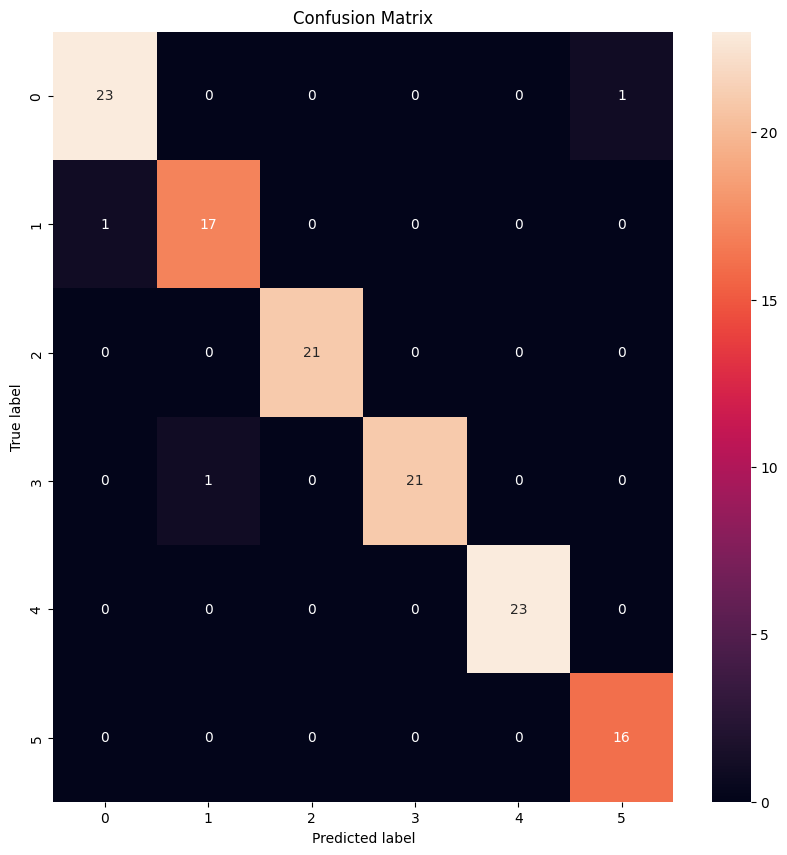

In [35]:
# confusion matrix using matplotlib seaborn with proper labels

plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


In [38]:
# predict for unseen value


prediction = model.predict([[83,78,135,5,1.25,0.33,18.50,52.06,88.67,40.62,71.34]])

print(prediction[0])

mango


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [39]:
# predict for unseen value
# N = int(input("Enter N: "))
# P = int(input("Enter P: "))
# K = int(input("Enter K: "))
# ph = float(input("Enter ph: "))
# EC = float(input("Enter EC: "))
# S = float(input("Enter S: "))
# Cu = float(input("Enter Cu: "))
# Fe = float(input("Enter Fe: "))
# Mn = float(input("Enter Mn: "))
# Zn = float(input("Enter Zn: "))
# B = float(input("Enter B: "))


# prediction = model.predict([[N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B]])

# print(prediction[0])

Enter N: 1
Enter P: 1
Enter K: 1
Enter ph: 1
Enter EC: 1
Enter S: 1
Enter Cu: 1
Enter Fe: 1
Enter Mn: 1
Enter Zn: 1
Enter B: 1
potato


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# Saving model using joblib (recommended)



```
!pip install joblib
```



In [40]:
# Saving model using joblib

import joblib

joblib.dump(model, 'crop_prediction_model.joblib')

['crop_prediction_model.joblib']

In [41]:
# Loading saved model
import joblib
loaded_model = joblib.load('crop_prediction_model.joblib')

In [42]:
prediction = loaded_model.predict([[83,78,135,5,1.25,0.33,18.50,52.06,88.67,40.62,71.34]])

print(prediction[0])

mango


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


OR (pickle alternative)

In [43]:
# saving model using pickle

# import pickle

# with open('crop_prediction_model.pkl', 'wb') as f:
#     pickle.dump(model, f)


# # Load saved model


# pkl_model = pickle.load(open('crop_prediction_model.pkl', 'rb'))